# House Price Prediction — Full Pipeline

This notebook combines all 5 tasks: data loading & exploration, cleaning, model building, visualization, and insights.

# Task 1 — Data Loading & Exploration

Load the Housing dataset and take a first look at its structure.

In [1]:
import pandas as pd

DATA_PATH = "dataset/Housing.csv"
df = pd.read_csv(DATA_PATH)
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Shape of the dataset

In [2]:
n_rows, n_cols = df.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 545
Columns: 13


## Target vs. Features

`price` is the target variable we want to predict. Every other column is a feature.

In [3]:
target = "price"
features = [c for c in df.columns if c != target]

print("Target column:", target)
print("Feature columns:", features)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Missing values per column

In [4]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# Task 2 — Data Cleaning

Handle missing values, drop duplicates, one-hot encode categorical columns, and keep only the columns useful for predicting price.

In [7]:
import pandas as pd

df = pd.read_csv("dataset/Housing.csv")
df.shape

(545, 13)

## Handle missing values

Numeric columns are filled with the median, categorical columns are filled with the mode. The dataset has no missing values, but this keeps the notebook robust if that ever changes.

In [8]:
for col in df.columns:
    if df[col].isna().sum() == 0:
        continue
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df.isna().sum().sum()

np.int64(0)

## Remove duplicate rows

In [9]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows")

Removed 0 duplicate rows


## Encode categorical columns

The yes/no columns are binary, so they are mapped to 1/0. `furnishingstatus` has three categories, so it is one-hot encoded.

In [10]:
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Keep meaningful columns

Every remaining column (size, rooms, amenities, location proxies) has a plausible relationship with price, so all are kept for modeling.

In [11]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

## Save the cleaned dataset for the next tasks

In [12]:
df.to_csv("dataset/Housing_cleaned.csv", index=False)
print("Saved cleaned dataset to dataset/Housing_cleaned.csv")

Saved cleaned dataset to dataset/Housing_cleaned.csv


# Task 3 — Model Building

Train a Linear Regression model and a Random Forest Regressor to predict house price, then compare them.

In [13]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("dataset/Housing_cleaned.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Train / test split (80/20)

In [14]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((436, 13), (109, 13))

## Linear Regression

In [15]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_preds)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_preds))
lin_r2 = r2_score(y_test, lin_preds)

print(f"Linear Regression -> MAE: {lin_mae:,.2f}  RMSE: {lin_rmse:,.2f}  R2: {lin_r2:.4f}")

Linear Regression -> MAE: 970,043.40  RMSE: 1,324,506.96  R2: 0.6529


## Random Forest Regressor

In [16]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
rf_preds = rf_reg.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest -> MAE: {rf_mae:,.2f}  RMSE: {rf_rmse:,.2f}  R2: {rf_r2:.4f}")

Random Forest -> MAE: 1,014,947.32  RMSE: 1,399,769.44  R2: 0.6124


## Compare the two models

In [17]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lin_mae, rf_mae],
    "RMSE": [lin_rmse, rf_rmse],
    "R2 Score": [lin_r2, rf_r2],
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Save the trained models

In [18]:
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(lin_reg, os.path.join(MODEL_DIR, "linear_regression_model.pkl"))
joblib.dump(rf_reg, os.path.join(MODEL_DIR, "random_forest_model.pkl"))
joblib.dump(list(X.columns), os.path.join(MODEL_DIR, "feature_columns.pkl"))

print("Models saved to", MODEL_DIR)

Models saved to model


# Task 4 — Visualization

Three charts: price distribution, a correlation heatmap, and an actual-vs-predicted scatter plot.

In [19]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

df = pd.read_csv("dataset/Housing_cleaned.csv")

CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

## Chart 1 — Distribution of house prices

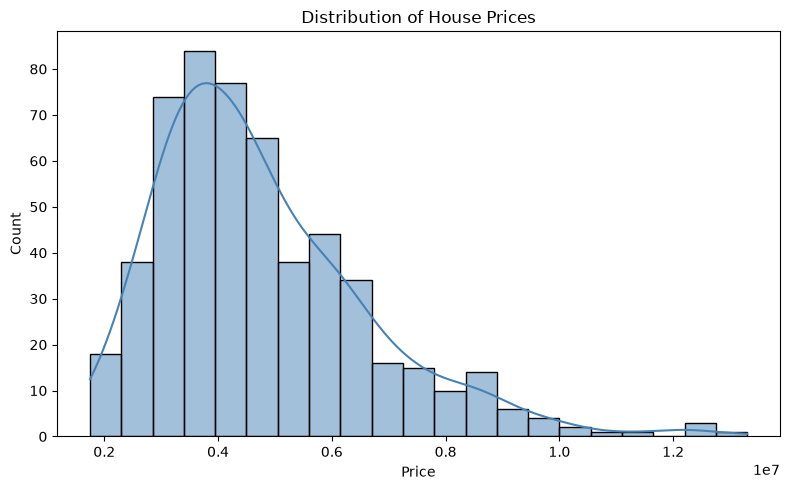

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "price_distribution.png"))
plt.show()

## Chart 2 — Correlation heatmap

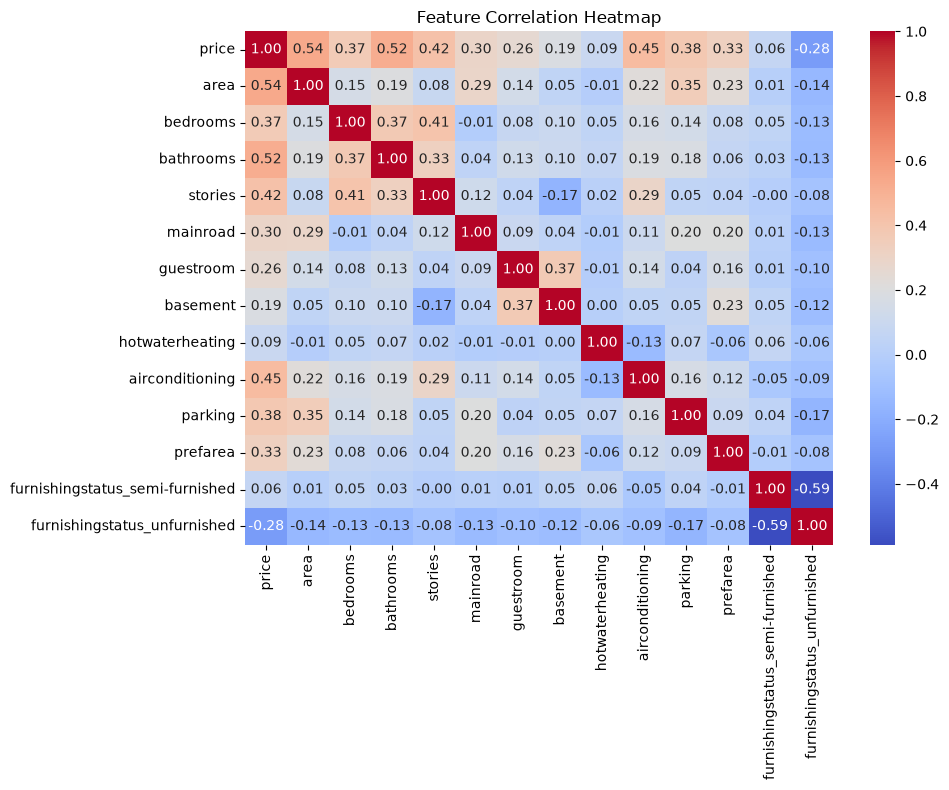

In [21]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "correlation_heatmap.png"))
plt.show()

## Chart 3 — Actual vs. Predicted price (Random Forest)

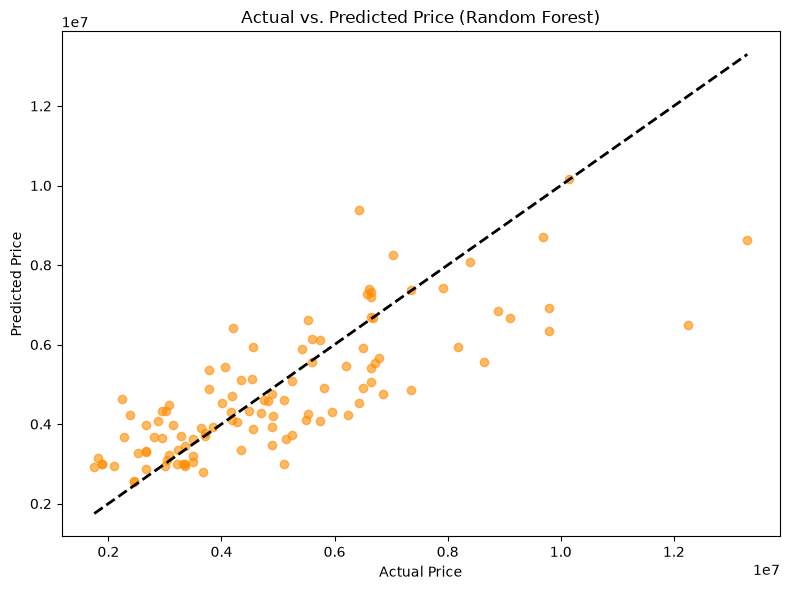

In [22]:
MODEL_DIR = "model"
rf_reg = joblib.load(os.path.join(MODEL_DIR, "random_forest_model.pkl"))
feature_columns = joblib.load(os.path.join(MODEL_DIR, "feature_columns.pkl"))

X = df[feature_columns]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preds = rf_reg.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, color="darkorange")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Price (Random Forest)")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "actual_vs_predicted.png"))
plt.show()

# Task 5 — Insights & Summary

In [23]:
import pandas as pd

df = pd.read_csv("dataset/Housing_cleaned.csv")
df.corr()["price"].sort_values(ascending=False)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

## Summary

**Which features influence house price the most?** Area, the number of bathrooms, air conditioning, and the number of stories show the strongest positive correlation with price, followed by parking spaces and whether the home is on the preferred ("prefarea") side of town. Bedrooms alone has a weaker relationship than expected.

**How accurate was your model (in plain terms)?** Both models explain about 60-65% of the variation in house price (R² ≈ 0.65 for Linear Regression, ≈ 0.61 for Random Forest), with a typical prediction error of roughly ₹1 million on houses priced in the multi-million range — useful for a ballpark estimate, but not precise enough to set a final listing price on its own.

**What surprised you in the data?** Linear Regression matched or slightly beat Random Forest here — with only ~545 rows and mostly linear-ish relationships (bigger area/more bathrooms → higher price), the simpler model had nothing to gain from Random Forest's extra flexibility. The number of bedrooms also barely correlates with price compared to area and bathrooms — bigger isn't always about room count, it's about usable space and amenities.

**One recommendation for a real estate business?** Price listings primarily off livable area and amenity count (bathrooms, AC, parking) rather than bedroom count alone, and use a model like this as a starting estimate that a human agent then adjusts for location-specific factors the dataset doesn't capture (exact neighborhood, school zones, condition).